# Analysis of simulated trajectorories

In [1]:
cd ~/work/tutorials/sources/OpenDrift/openberg_custom_juliette 

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette


In [2]:
# import pandas as pd
# import xarray as xr
# import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import glob
from src.utils import *
from src.utils2 import *

In [3]:
# Read and subset tracker data
ds_3day = read_tracker('./input/Osker-X2.csv')['3D']
ds = read_tracker('./input/Osker-X2.csv')['full']

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette/src/utils2.py:108: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette/src/utils2.py:108: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [4]:
sim = xr.open_dataset('./results/juliette_topaz5_windglophynrt.nc')
sim

<xarray.Dataset> Size: 82MB
Dimensions:                                   (trajectory: 260, time: 1872)
Coordinates:
  * trajectory                                (trajectory) int32 1kB 0 1 ... 259
  * time                                      (time) datetime64[ns] 15kB 2025...
Data variables: (12/39)
    status                                    (trajectory, time) float64 4MB ...
    moving                                    (trajectory, time) float64 4MB ...
    age_seconds                               (trajectory, time) float32 2MB ...
    origin_marker                             (trajectory, time) float64 4MB ...
    lon                                       (trajectory, time) float32 2MB ...
    lat                                       (trajectory, time) float32 2MB ...
    ...                                        ...
    sea_water_salinity                        (trajectory, time) float32 2MB ...
    sea_ice_area_fraction                     (trajectory, time) float32 2MB ...
    sea_ice_thickness                         (trajectory, time) float32 2MB ...
    sea_ice_x_velocity                        (trajectory, time) float32 2MB ...
    sea_ice_y_velocity                        (trajectory, time) float32 2MB ...
    land_binary_mask                          (trajectory, time) float32 2MB ...
Attributes: (12/147)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               0.0
    geospatial_vertical_max:                                               0.0
    geospatial_vertical_positive:                                          up

In [5]:
# def colour_finder(sim_in,by='reader_'):
#     #pick colormap
#     cmap = plt.get_cmap('tab20')  # or 'viridis', 'plasma', etc.
#     colors = cmap(np.linspace(0, 1, 20))#20 colors
#     if by=='reader_x_sea_water_velocity': 
#         val = sim_in.reader_x_sea_water_velocity
#     return col_dict

In [4]:
# --- Which simulation data for plot? ---
file_contain_all = ['_','nextsim'] #list of key words that should ALL be contained in file name, if none required, write '_'
# file_contain_any = ['topaz5','topaz6-lowres_topaz5',] #list of key words that, from which at least one should be contained in file name, if none required, write '_'
file_contain_any = ['topaz5','topaz6-lowres','glophyanfc'] #list of key words that, from which at least one should be contained in file name, if none required, write '_'
file_notcontain = ['wam',] #list of keywords that should not be in filename
file_l = glob.glob("./results/*.nc")#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
file_l

['./results/juliette_nextsimanfc_topaz6-lowres_topaz4_windglophynrt.nc',
 './results/juliette_nextsimanfc_glophyanfc_windglophynrt.nc',
 './results/juliette_nextsimanfc_topaz6-lowres_topaz5_windglophynrt.nc',
 './results/juliette_nextsimanfc_topaz5_windglophynrt.nc']

0 ./results/juliette_nextsimanfc_topaz6-lowres_topaz4_windglophynrt.nc [0.12156863 0.46666667 0.70588235 1.        ]
1 ./results/juliette_nextsimanfc_glophyanfc_windglophynrt.nc [0.68235294 0.78039216 0.90980392 1.        ]
2 ./results/juliette_nextsimanfc_topaz6-lowres_topaz5_windglophynrt.nc [1.         0.49803922 0.05490196 1.        ]
3 ./results/juliette_nextsimanfc_topaz5_windglophynrt.nc [1.         0.73333333 0.47058824 1.        ]


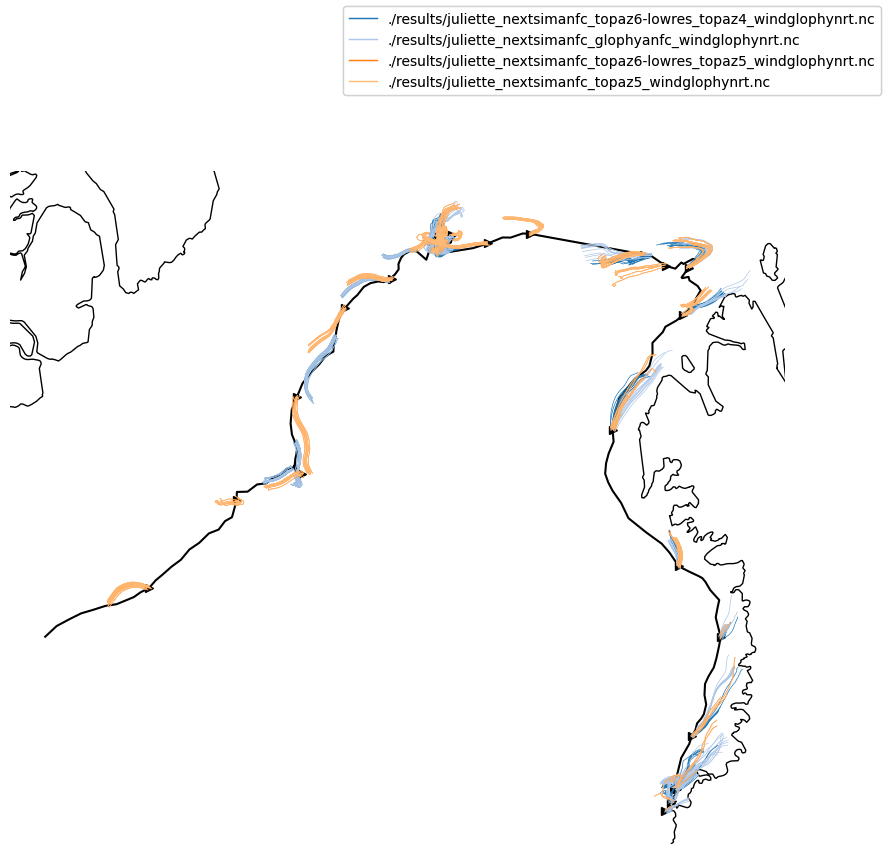

In [6]:
# Map plot comparing simulations with different input

#def
note = 'nextsim'
#by = inputdataidx
cmap = plt.get_cmap('tab20')  # or 'viridis', 'plasma', etc.
col = cmap(np.linspace(0, 1, 20))#20 colors

#Figure
fig,ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.NorthPolarStereo()})#central_longitude=20})
ax.coastlines(resolution='10m')
trans = ccrs.PlateCarree()
#ax.set_extent((-42.5, -11, 65, 78))

# plot obs
ax.plot(ds_3day['lon'],ds_3day['lat'],'>',transform=trans,color='k')
ax.plot(ds['lon'],ds['lat'],transform=trans,color='k',label='Observation')

# plot sim
for inputdataidx, inputdata in enumerate(file_l):
    print(inputdataidx, inputdata, col[inputdataidx])
    dssim = xr.open_dataset(inputdata)
    for traj in dssim.trajectory: #goes trhough trajectories with different coefficients, size, time and position
        ax.plot(dssim.lon[traj].dropna(dim="time"),dssim.lat[traj].dropna(dim="time"),
                color=col[inputdataidx],linewidth=0.5,
                transform=trans)
#legend
legend_elements = [Line2D([0], [0],linestyle='-', color=col[idx], lw=1,label=file_l[idx]) for idx in range(inputdataidx+1)]
leg = fig.legend(handles=legend_elements,)#fontsize=fs,ncol=len(legend_elements0+legend_elements2),                  columnspacing=0.6,labelspacing=0.3,loc='center',bbox_to_anchor=bbox_dict[kw][0])
plt.axis('off')
fig.add_artist(leg)
# plt.savefig('./results/map_%s.png'%note,dpi=200,transparent=True,bbox_inches='tight')
plt.show()

